In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
from pyspark.ml.evaluation import ClusteringEvaluator
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MEF_Gastos_Segmentacion") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("SparkSession creada")

SparkSession creada


In [3]:
paths = [
    "parquet/raw/year/ANO_EJE=2022/",
    "parquet/raw/year/ANO_EJE=2023/",
    "parquet/raw/year/ANO_EJE=2024/",
    "parquet/raw/year/ANO_EJE=2025/"
]

df = spark.read.option("basePath", "parquet/raw/year/").parquet(*paths)

print("✅ Datos cargados:", df.count(), "registros")
df.printSchema()

✅ Datos cargados: 40173892 registros
root
 |-- MES_EJE: integer (nullable = true)
 |-- NIVEL_GOBIERNO: string (nullable = true)
 |-- NIVEL_GOBIERNO_NOMBRE: string (nullable = true)
 |-- SECTOR: string (nullable = true)
 |-- SECTOR_NOMBRE: string (nullable = true)
 |-- PLIEGO: string (nullable = true)
 |-- PLIEGO_NOMBRE: string (nullable = true)
 |-- SEC_EJEC: integer (nullable = true)
 |-- EJECUTORA: integer (nullable = true)
 |-- EJECUTORA_NOMBRE: string (nullable = true)
 |-- DEPARTAMENTO_EJECUTORA: integer (nullable = true)
 |-- DEPARTAMENTO_EJECUTORA_NOMBRE: string (nullable = true)
 |-- PROVINCIA_EJECUTORA: integer (nullable = true)
 |-- PROVINCIA_EJECUTORA_NOMBRE: string (nullable = true)
 |-- DISTRITO_EJECUTORA: integer (nullable = true)
 |-- DISTRITO_EJECUTORA_NOMBRE: string (nullable = true)
 |-- SEC_FUNC: integer (nullable = true)
 |-- PROGRAMA_PPTO: integer (nullable = true)
 |-- PROGRAMA_PPTO_NOMBRE: string (nullable = true)
 |-- TIPO_ACT_PROY: integer (nullable = true)
 |-

In [4]:
features_cols = [
    "MONTO_PIA", "MONTO_PIM", "MONTO_CERTIFICADO",
    "MONTO_COMPROMETIDO", "MONTO_DEVENGADO", "MONTO_GIRADO"
]

In [5]:
assembler = VectorAssembler(inputCols=features_cols, outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)

In [6]:
df_assembled = assembler.transform(df)               
scaler_model = scaler.fit(df_assembled)              
df_features = scaler_model.transform(df_assembled)   

df_features = df_features.cache()

In [7]:
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=4, seed=42)

In [8]:
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

In [9]:
model = pipeline.fit(df)

In [10]:
clusters = model.transform(df)

In [11]:
clusters.select("ANO_EJE", "PLIEGO", "PLIEGO_NOMBRE", "MONTO_DEVENGADO", "cluster").show(10, truncate=False)

+-------+------+----------------------------------------------+---------------+-------+
|ANO_EJE|PLIEGO|PLIEGO_NOMBRE                                 |MONTO_DEVENGADO|cluster|
+-------+------+----------------------------------------------+---------------+-------+
|2022   |440   |GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS|84.0           |0      |
|2022   |      |                                              |0.0            |0      |
|2022   |440   |GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS|1025.0         |0      |
|2022   |      |                                              |0.0            |0      |
|2022   |440   |GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS|0.0            |0      |
|2022   |      |                                              |0.0            |0      |
|2022   |440   |GOBIERNO REGIONAL DEL DEPARTAMENTO DE AMAZONAS|112966.17      |0      |
|2022   |      |                                              |0.0            |0      |
|2022   |440   |GOBIERNO REGIONA

In [12]:
evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)
silhouette = evaluator.evaluate(clusters)
print("Silhouette score (k=4):", silhouette)

Silhouette score (k=4): 0.9999986058378206


In [13]:
avg_clusters = clusters.groupBy("cluster").avg(*features_cols).orderBy("cluster")
avg_clusters.show(truncate=False)

+-------+-----------------+------------------+----------------------+-----------------------+--------------------+--------------------+
|cluster|avg(MONTO_PIA)   |avg(MONTO_PIM)    |avg(MONTO_CERTIFICADO)|avg(MONTO_COMPROMETIDO)|avg(MONTO_DEVENGADO)|avg(MONTO_GIRADO)   |
+-------+-----------------+------------------+----------------------+-----------------------+--------------------+--------------------+
|0      |21470.70204551346|24341.801404838377|23575.293524730154    |20374.854179474813     |19848.480965545947  |19722.211579178802  |
|1      |1.0459631557E10  |9.5337240445E9    |0.0                   |0.0                    |0.0                 |0.0                 |
|2      |0.0              |0.0               |0.0                   |4.1960746126257143E9   |1.1348667855999999E8|1.1348667855999999E8|
|3      |0.0              |0.0               |0.0                   |4.195771985171429E8    |4.553141464328571E9 |4.553141464328571E9 |
+-------+-----------------+------------------+--

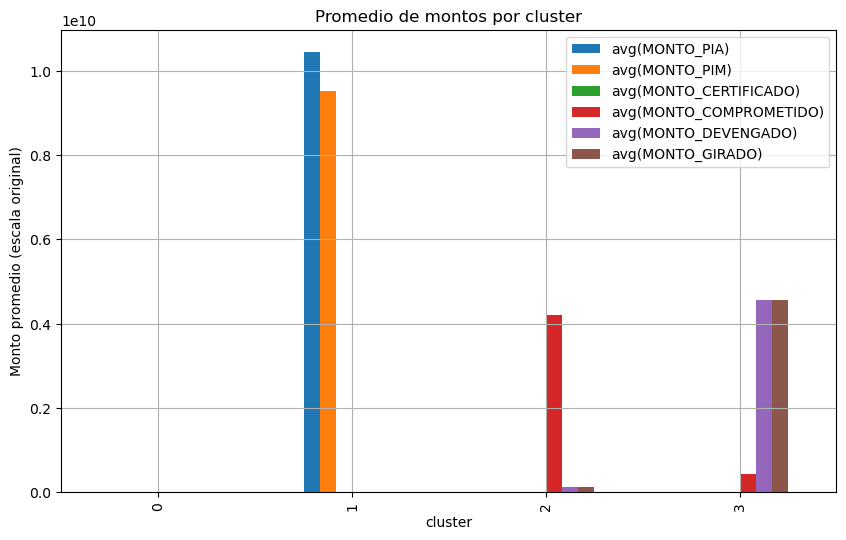

In [14]:
avg_pd = avg_clusters.toPandas()
avg_pd.plot(kind="bar", x="cluster", figsize=(10,6))
plt.title("Promedio de montos por cluster")
plt.ylabel("Monto promedio (escala original)")
plt.grid(True)
plt.show()

In [15]:
cluster_year = clusters.groupBy("ANO_EJE", "cluster") \
    .agg(
        F.avg("MONTO_DEVENGADO").alias("avg_devengado"),
        F.avg("MONTO_GIRADO").alias("avg_girado")
    ) \
    .orderBy("ANO_EJE", "cluster")
cluster_year.show(truncate=False)

+-------+-------+--------------------+--------------------+
|ANO_EJE|cluster|avg_devengado       |avg_girado          |
+-------+-------+--------------------+--------------------+
|2022   |0      |19475.25509230521   |19437.87587075861   |
|2022   |1      |0.0                 |0.0                 |
|2022   |2      |5.994057788E7       |5.994057788E7       |
|2022   |3      |4.00322916652E9     |4.00322916652E9     |
|2023   |0      |19978.366408620906  |19942.945392370246  |
|2023   |1      |0.0                 |0.0                 |
|2023   |2      |6.331745661E7       |6.331745661E7       |
|2023   |3      |4.1808279651450005E9|4.1808279651450005E9|
|2024   |0      |20469.528796459916  |20435.578027805415  |
|2024   |1      |0.0                 |0.0                 |
|2024   |2      |2.4044431658999997E8|2.4044431658999997E8|
|2024   |3      |4.74032864054E9     |4.74032864054E9     |
|2025   |0      |19276.144510656282  |18767.611812295323  |
|2025   |1      |0.0                 |0.

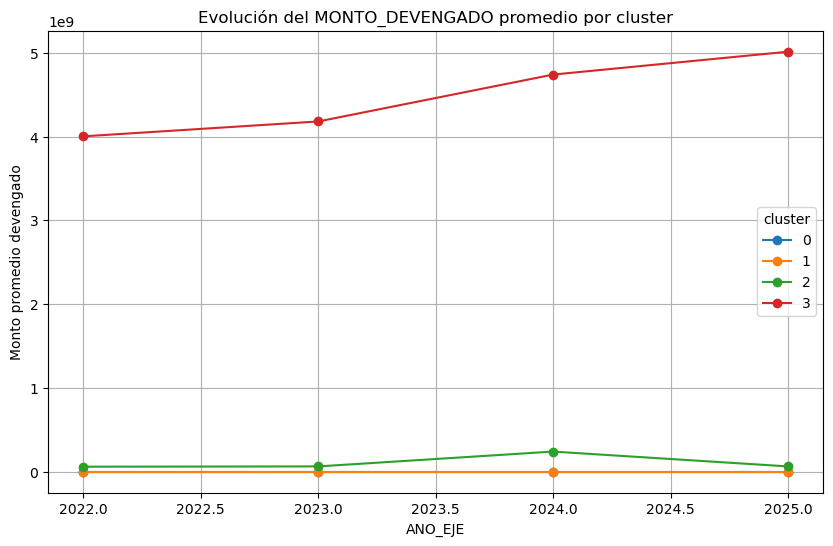

In [16]:
cluster_year_pd = cluster_year.toPandas()
cluster_year_pd.pivot(index="ANO_EJE", columns="cluster", values="avg_devengado").plot(
    marker="o", figsize=(10,6))
plt.title("Evolución del MONTO_DEVENGADO promedio por cluster")
plt.ylabel("Monto promedio devengado")
plt.grid(True)
plt.show()

In [17]:
top_pliegos = clusters.groupBy("cluster", "PLIEGO_NOMBRE") \
    .agg(F.sum("MONTO_DEVENGADO").alias("total_devengado")) \
    .orderBy("cluster", F.desc("total_devengado"))

top_pliegos.show(20, truncate=False)

+-------+--------------------------------------------------+---------------------+
|cluster|PLIEGO_NOMBRE                                     |total_devengado      |
+-------+--------------------------------------------------+---------------------+
|0      |                                                  |1.3825696909378415E11|
|0      |M. DE ECONOMIA Y FINANZAS                         |5.884527903770001E10 |
|0      |M. DEL INTERIOR                                   |4.687689571671999E10 |
|0      |MINISTERIO DE TRANSPORTES Y COMUNICACIONES        |3.632235765398E10    |
|0      |M. DE DEFENSA                                     |3.480712102348E10    |
|0      |M. DE SALUD                                       |3.442548521421015E10 |
|0      |M. DE EDUCACION                                   |3.159760410281002E10 |
|0      |OFICINA DE NORMALIZACION PREVISIONAL-ONP          |2.9816426056270004E10|
|0      |MINISTERIO DE DESARROLLO E INCLUSION SOCIAL       |2.428401079873999E10 |
|0  

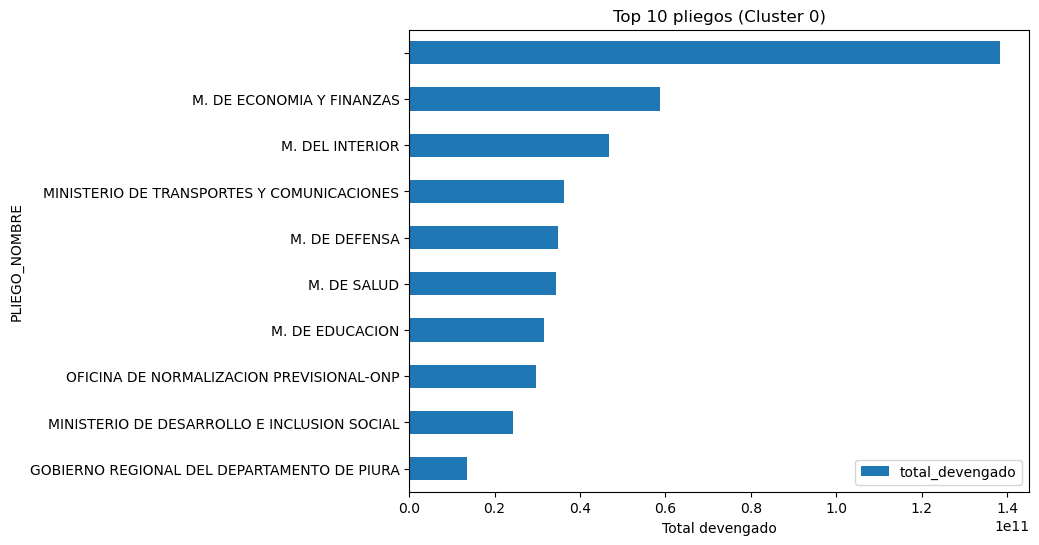

In [18]:
top_pliegos_pd = top_pliegos.filter(F.col("cluster")==0).limit(10).toPandas()
top_pliegos_pd.plot(kind="barh", x="PLIEGO_NOMBRE", y="total_devengado", figsize=(8,6))
plt.title("Top 10 pliegos (Cluster 0)")
plt.xlabel("Total devengado")
plt.gca().invert_yaxis()
plt.show()